# Exploratory Data Analysis

## Objective

Explore numerical and categorical variables, compare default and non-default applicants, and identify relationships useful for feature engineering.

## Inputs

Processed application dataset

## Outputs

- Numerical summaries
- Default-rate comparisons
- Correlation analysis
- Feature engineering ideas

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings('ignore')

### 2. Load Data

In [2]:
app = pd.read_csv('application_train.csv', nrows=50000)

### 3. Target Distribution

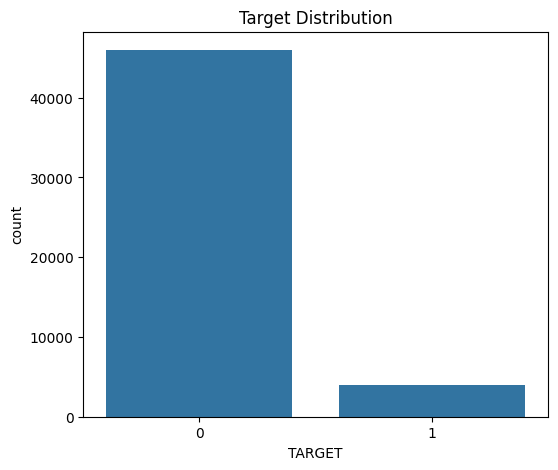

In [3]:
# counts
app['TARGET'].value_counts()

# percentages
app['TARGET'].value_counts(
    normalize=True
) * 100

# visualization
plt.figure(figsize=(6, 5))

sns.countplot(
    x='TARGET',
    data=app
)

plt.title('Target Distribution')
plt.show()

### 4. Missing Value Analytics

In [4]:
missing_df = pd.DataFrame({
    'Missing %':
        app.isnull().mean() * 100
})

missing_df = (
    missing_df
    .sort_values(
        by='Missing %',
        ascending=False
    )
)

missing_df.head(20)

,Missing %
COMMONAREA_AVG,69.922
COMMONAREA_MODE,69.922
COMMONAREA_MEDI,69.922
NONLIVINGAPARTMENTS_MEDI,69.430
NONLIVINGAPARTMENTS_MODE,69.430
NONLIVINGAPARTMENTS_AVG,69.430
LIVINGAPARTMENTS_AVG,68.454
LIVINGAPARTMENTS_MODE,68.454
LIVINGAPARTMENTS_MEDI,68.454
FONDKAPREMONT_MODE,68.384


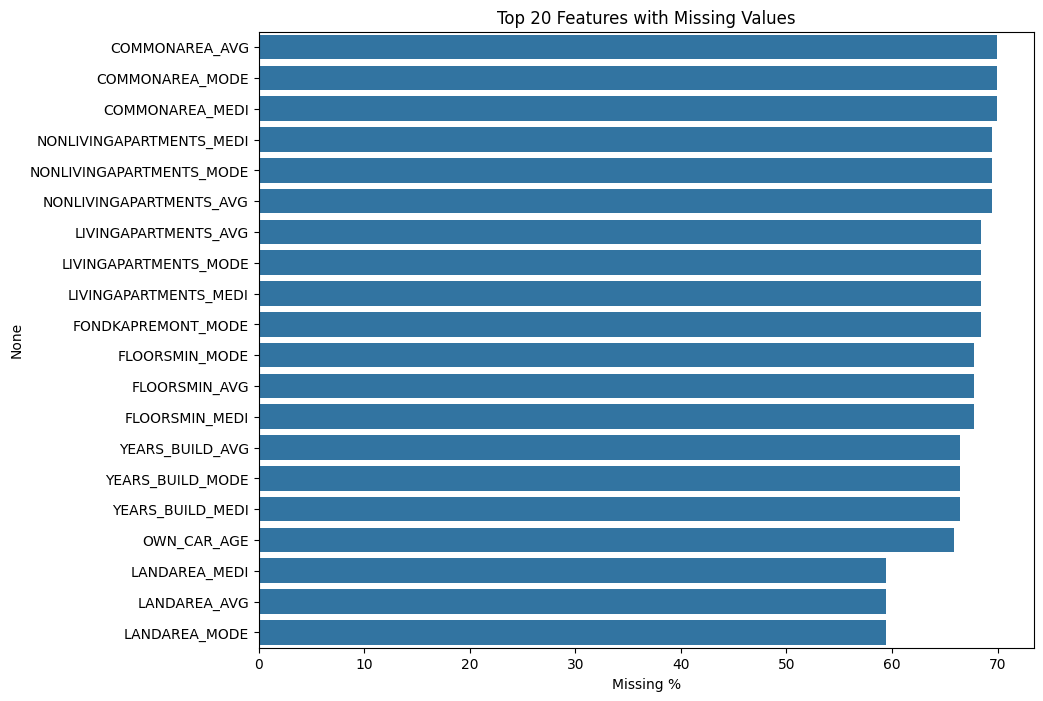

In [5]:
# visualization
plt.figure(figsize=(10, 8))

sns.barplot(
    x=missing_df.head(20)['Missing %'],
    y=missing_df.head(20).index
)

plt.title('Top 20 Features with Missing Values')
plt.show()

### 5. Numerical Feature Analysis

Before plotting, create some useful features.
#### Age & Employment Years
DAYS_BIRTH & DAYS_EMPLOYED is stored in negative days.\
Convert to years.

In [6]:
app['AGE'] = app['DAYS_BIRTH'].abs() / 365

# Replace anomalous employment value with NaN (applicants who are not currently employed/pensioners)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)

# Convert employment duration from days to years
app['EMPLOYMENT_YEARS'] = app['DAYS_EMPLOYED'].abs() / 365

#### Analyze AGE
##### Distribution

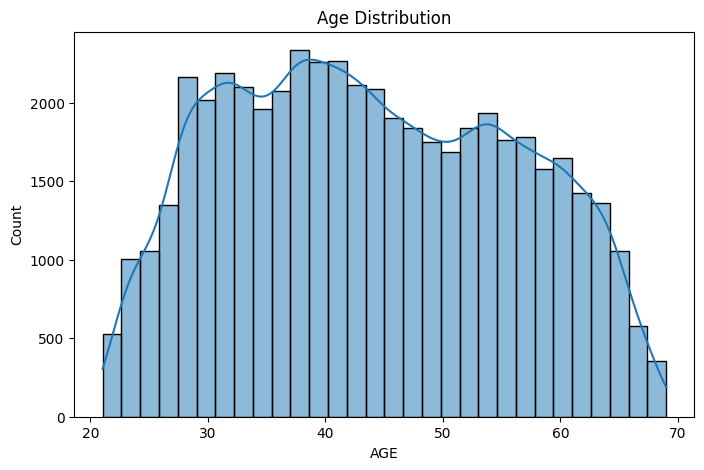

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    app['AGE'],
    bins=30,
    kde=True
)

plt.title('Age Distribution')
plt.show()

##### Age vs Default

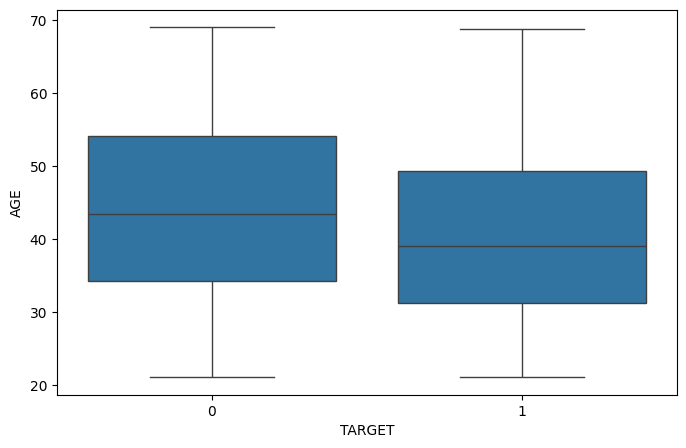

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='TARGET',
    y='AGE',
    data=app
)

plt.show()

#### Analyze Income
##### Distribution

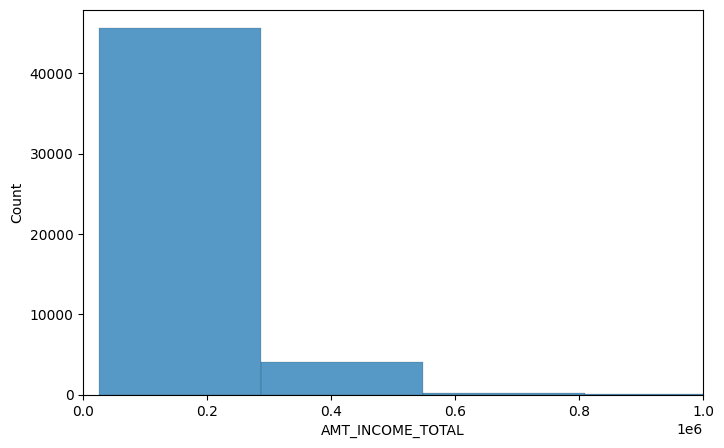

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    app['AMT_INCOME_TOTAL']
    #bins=50
)

plt.xlim(0, 1000000)
plt.show()

##### Income vs Default

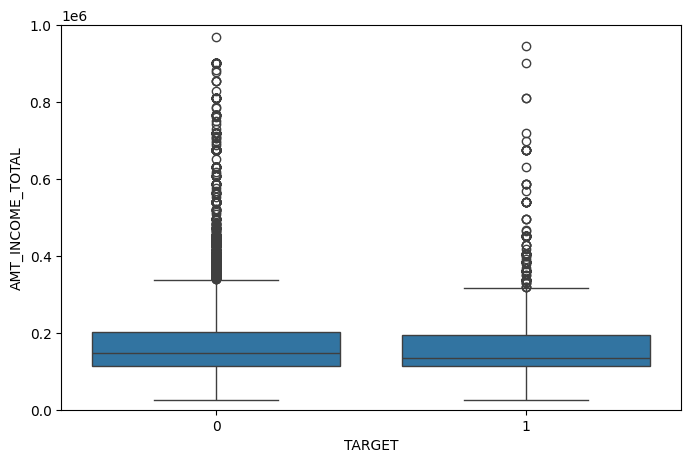

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=app
)

plt.ylim(0, 1000000)
plt.show()

#### Analyze Credit Amount

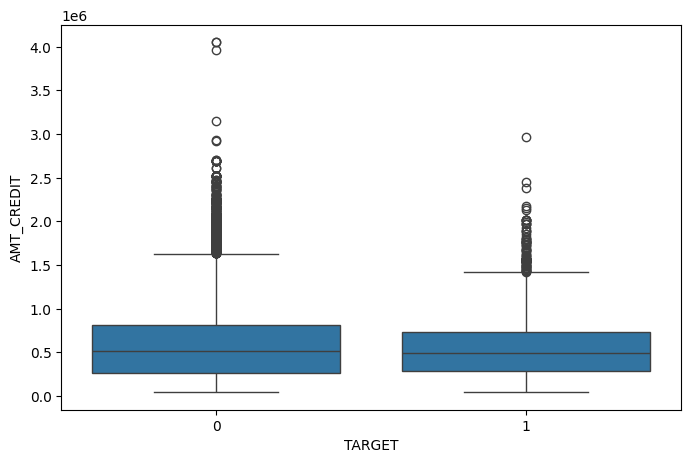

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='TARGET',
    y='AMT_CREDIT',
    data=app
)

plt.show()

#### Analyze Credit Annuity

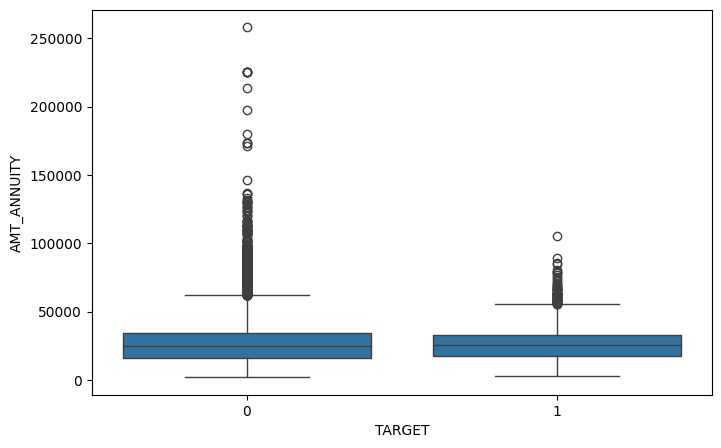

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='TARGET',
    y='AMT_ANNUITY',
    data=app
)

plt.show()

#### Analyze Employment Years

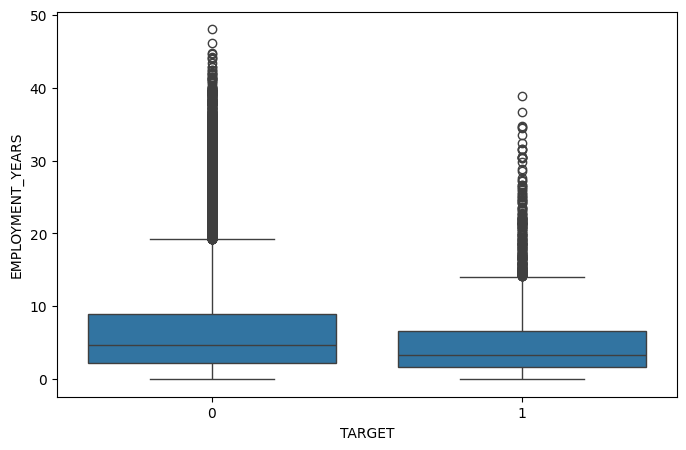

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='TARGET',
    y='EMPLOYMENT_YEARS',
    data=app
)

plt.show()

In [14]:
features = [
    'AGE',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'EMPLOYMENT_YEARS'
]

summary = app.groupby('TARGET')[features].agg(
    ['median', 'mean']
).T

summary

TARGET                               0              1
AGE              median      43.465753      38.997260
                 mean        44.167725      40.795483
AMT_INCOME_TOTAL median  148500.000000  135000.000000
                 mean    169050.941789  190344.823770
AMT_CREDIT       median  518463.000000  497520.000000
                 mean    603556.649334  555603.521982
AMT_ANNUITY      median   24907.500000   25303.500000
                 mean     27160.572858   26497.216095
EMPLOYMENT_YEARS median       4.641096       3.369863
                 mean         6.722393       4.960400

In [15]:
app[features].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
AGE,50000.0,43.896192,11.948995,21.041096,33.914384,43.098630,53.819178,6.355342e+01,6.692058e+01,6.899726e+01
AMT_INCOME_TOTAL,50000.0,170765.525166,531813.977328,25650.000000,112500.000000,145800.000000,202500.000000,3.375000e+05,4.770225e+05,1.170000e+08
AMT_CREDIT,50000.0,599695.463520,402413.036950,45000.000000,270000.000000,514777.500000,808650.000000,1.350000e+06,1.847702e+06,4.050000e+06
AMT_ANNUITY,49999.0,27107.158303,14562.881171,2052.000000,16456.500000,24939.000000,34596.000000,5.324850e+04,7.000704e+04,2.580255e+05
EMPLOYMENT_YEARS,41076.0,6.571271,6.446749,0.000000,2.103425,4.534247,8.769863,2.021712e+01,3.115205e+01,4.803014e+01


# 6. CATEGORICAL FEATURE ANALYSIS

In [16]:
categorical_features = [
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

In [17]:
def categorical_default_analysis(df, column):
    """
    Displays:
    1. Applicant count
    2. Default count
    3. Default rate
    for each category.
    """

    summary = (
        df.groupby(column, dropna=False)
          .agg(
              APPLICANT_COUNT=('TARGET', 'size'),
              DEFAULT_COUNT=('TARGET', 'sum'),
              DEFAULT_RATE=('TARGET', 'mean')
          )
          .reset_index()
    )

    summary['DEFAULT_RATE'] = summary['DEFAULT_RATE'] * 100

    summary = summary.sort_values(
        'DEFAULT_RATE',
        ascending=False
    )

    return summary

#### Gender Analysis

In [18]:
gender_summary = categorical_default_analysis(
    app,
    'CODE_GENDER'
)

gender_summary

,CODE_GENDER,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
1,M,17174,1762,10.259695
0,F,32824,2264,6.897392
2,XNA,2,0,0.000000


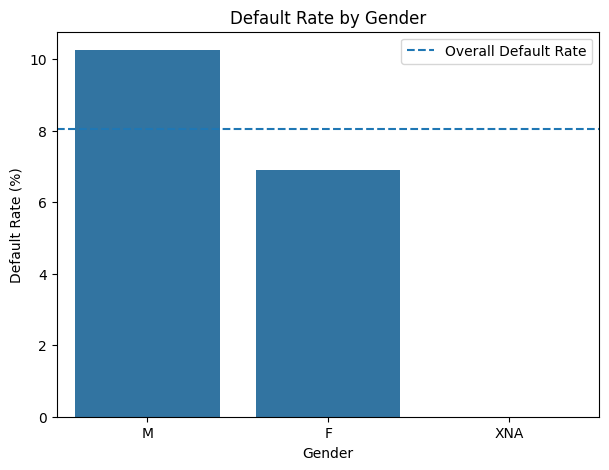

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_summary,
    x='CODE_GENDER',
    y='DEFAULT_RATE'
)

plt.title('Default Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Default Rate (%)')

overall_default_rate = app['TARGET'].mean() * 100

plt.axhline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Education Analysis

In [20]:
education_summary = categorical_default_analysis(
    app,
    'NAME_EDUCATION_TYPE'
)

education_summary

,NAME_EDUCATION_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
3,Lower secondary,620,73,11.774194
4,Secondary / secondary special,35573,3209,9.020887
2,Incomplete higher,1620,138,8.518519
1,Higher education,12167,606,4.980685
0,Academic degree,20,0,0.000000


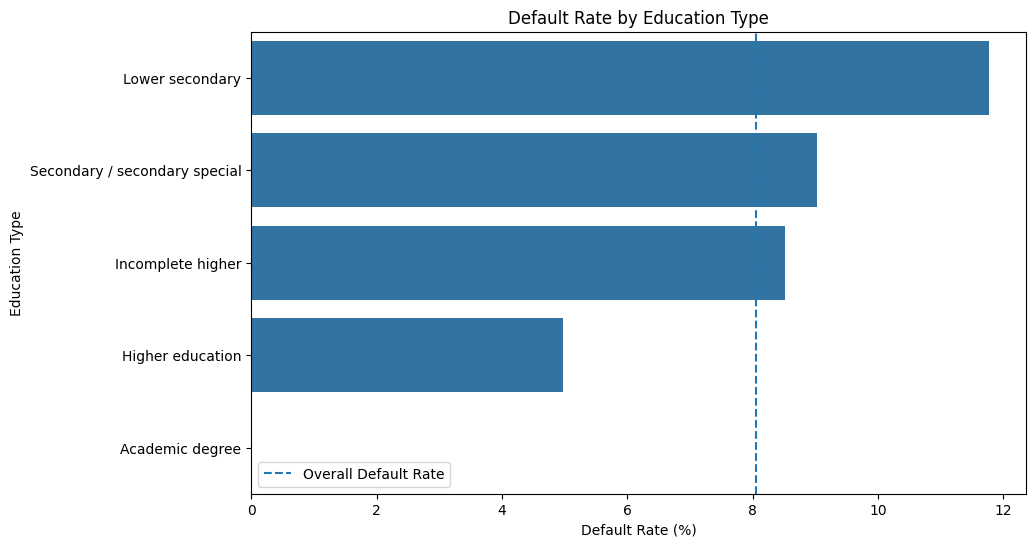

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_summary,
    x='DEFAULT_RATE',
    y='NAME_EDUCATION_TYPE'
)

plt.title('Default Rate by Education Type')
plt.xlabel('Default Rate (%)')
plt.ylabel('Education Type')

plt.axvline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Income Type Analysis

In [22]:
income_summary = categorical_default_analysis(
    app,
    'NAME_INCOME_TYPE'
)

income_summary

,NAME_INCOME_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
6,Unemployed,6,2,33.333333
7,Working,26010,2461,9.461745
1,Commercial associate,11543,864,7.485056
4,State servant,3513,198,5.636208
3,Pensioner,8920,501,5.616592
0,Businessman,2,0,0.000000
2,Maternity leave,1,0,0.000000
5,Student,5,0,0.000000


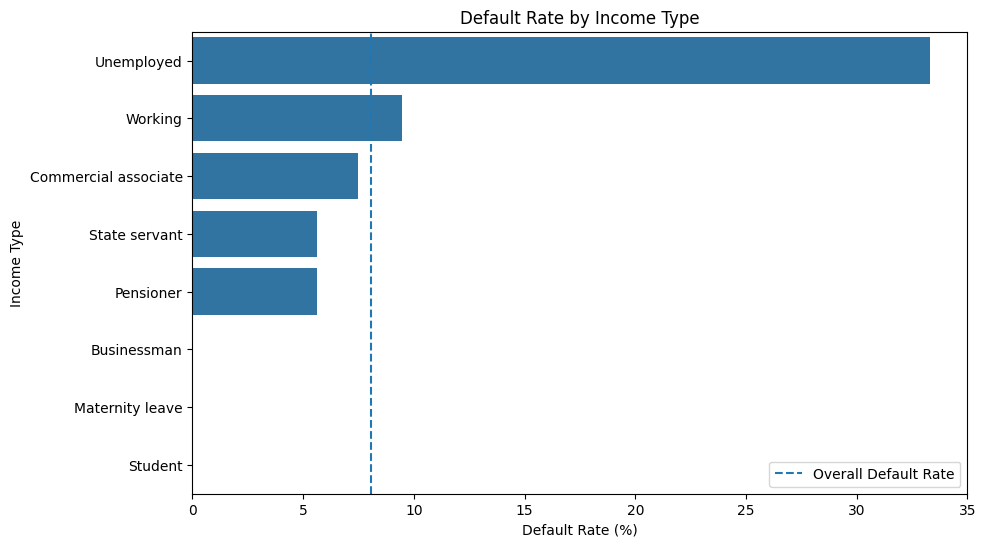

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=income_summary,
    x='DEFAULT_RATE',
    y='NAME_INCOME_TYPE'
)

plt.title('Default Rate by Income Type')
plt.xlabel('Default Rate (%)')
plt.ylabel('Income Type')

plt.axvline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Family Status Analysis

In [24]:
family_summary = categorical_default_analysis(
    app,
    'NAME_FAMILY_STATUS'
)

family_summary

,NAME_FAMILY_STATUS,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
3,Single / not married,7306,729,9.978100
0,Civil marriage,4859,482,9.919737
2,Separated,3142,272,8.656906
1,Married,32095,2395,7.462222
5,Widow,2597,148,5.698883
4,Unknown,1,0,0.000000


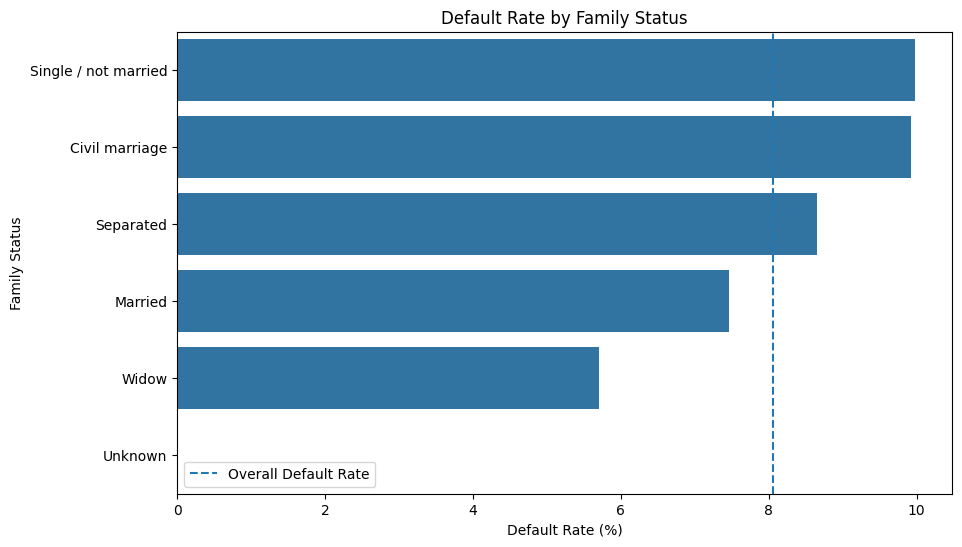

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=family_summary,
    x='DEFAULT_RATE',
    y='NAME_FAMILY_STATUS'
)

plt.title('Default Rate by Family Status')
plt.xlabel('Default Rate (%)')
plt.ylabel('Family Status')

plt.axvline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Housing Type Analysis

In [26]:
housing_summary = categorical_default_analysis(
    app,
    'NAME_HOUSING_TYPE'
)

housing_summary

,NAME_HOUSING_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
5,With parents,2399,277,11.546478
4,Rented apartment,769,87,11.313394
2,Municipal apartment,1845,145,7.859079
0,Co-op apartment,191,15,7.853403
1,House / apartment,44369,3473,7.827537
3,Office apartment,427,29,6.791569


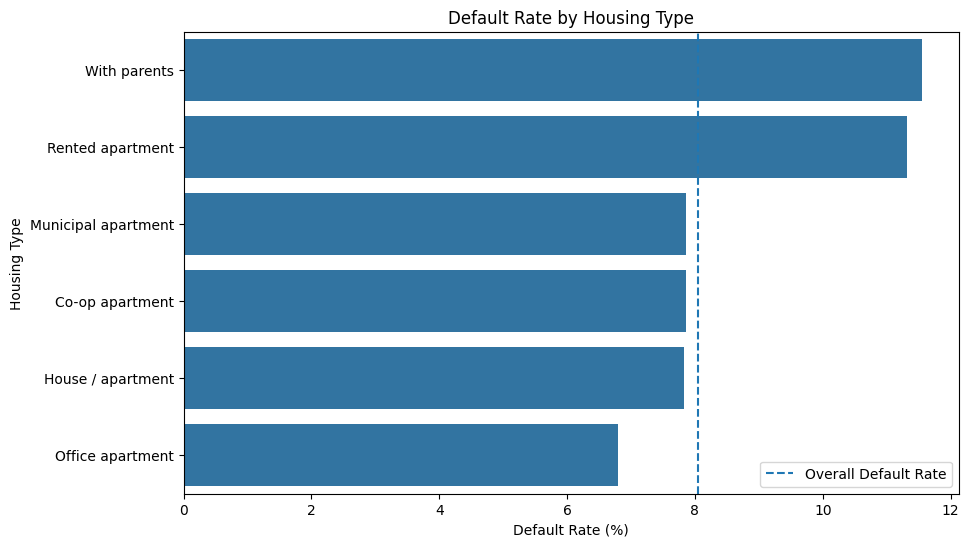

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=housing_summary,
    x='DEFAULT_RATE',
    y='NAME_HOUSING_TYPE'
)

plt.title('Default Rate by Housing Type')
plt.xlabel('Default Rate (%)')
plt.ylabel('Housing Type')

plt.axvline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Occupation Analysis

In [28]:
occupation_summary = categorical_default_analysis(
    app,
    'OCCUPATION_TYPE'
)

occupation_summary

,OCCUPATION_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
9,Low-skill Laborers,357,61,17.086835
4,Drivers,3044,338,11.103811
16,Security staff,1140,125,10.964912
17,Waiters/barmen staff,228,25,10.964912
13,Realty agents,123,13,10.569106
2,Cooking staff,963,101,10.488058
8,Laborers,8952,920,10.277033
14,Sales staff,5160,492,9.534884
1,Cleaning staff,739,68,9.201624
5,HR staff,101,9,8.910891


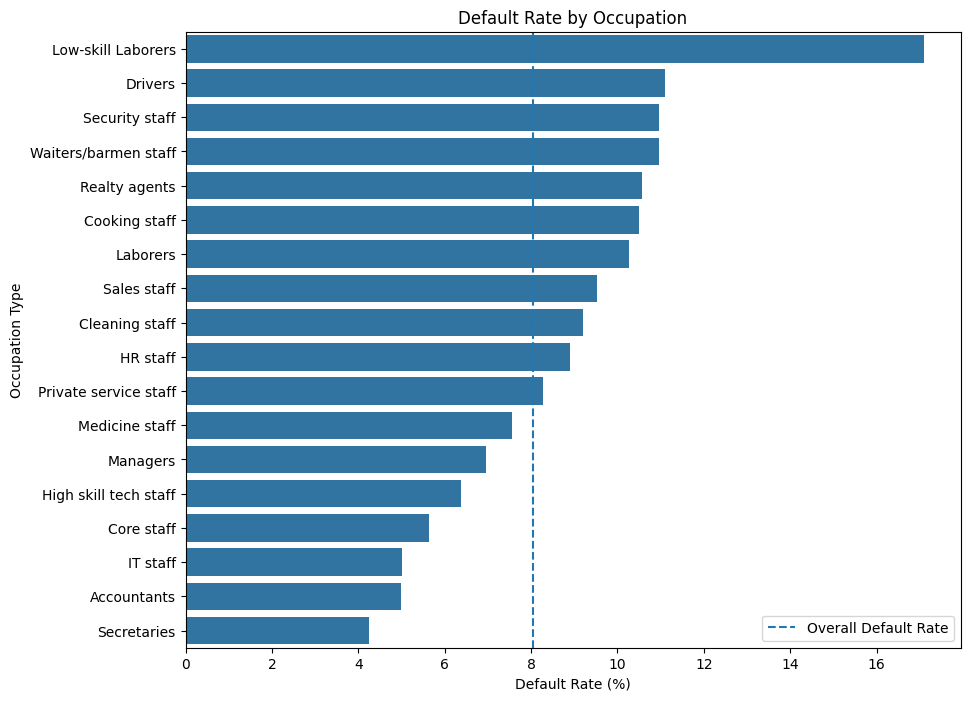

In [29]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=occupation_summary,
    x='DEFAULT_RATE',
    y='OCCUPATION_TYPE'
)

plt.title('Default Rate by Occupation')
plt.xlabel('Default Rate (%)')
plt.ylabel('Occupation Type')

plt.axvline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.legend()

plt.show()

#### Add the Overall Default Rate to the Plots

In [30]:
overall_default_rate = app['TARGET'].mean() * 100

#### Create a Combined Summary Table

In [31]:
for feature in categorical_features:

    print("=" * 80)
    print(feature)
    print("=" * 80)

    display(
        categorical_default_analysis(
            app,
            feature
        )
    )

CODE_GENDER


,CODE_GENDER,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
1,M,17174,1762,10.259695
0,F,32824,2264,6.897392
2,XNA,2,0,0.000000


NAME_EDUCATION_TYPE


,NAME_EDUCATION_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
3,Lower secondary,620,73,11.774194
4,Secondary / secondary special,35573,3209,9.020887
2,Incomplete higher,1620,138,8.518519
1,Higher education,12167,606,4.980685
0,Academic degree,20,0,0.000000


NAME_INCOME_TYPE


...

,NAME_FAMILY_STATUS,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
3,Single / not married,7306,729,9.978100
0,Civil marriage,4859,482,9.919737
2,Separated,3142,272,8.656906
1,Married,32095,2395,7.462222
5,Widow,2597,148,5.698883
4,Unknown,1,0,0.000000


NAME_HOUSING_TYPE


,NAME_HOUSING_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
5,With parents,2399,277,11.546478
4,Rented apartment,769,87,11.313394
2,Municipal apartment,1845,145,7.859079
0,Co-op apartment,191,15,7.853403
1,House / apartment,44369,3473,7.827537
3,Office apartment,427,29,6.791569


OCCUPATION_TYPE


,OCCUPATION_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
9,Low-skill Laborers,357,61,17.086835
4,Drivers,3044,338,11.103811
16,Security staff,1140,125,10.964912
17,Waiters/barmen staff,228,25,10.964912
13,Realty agents,123,13,10.569106
2,Cooking staff,963,101,10.488058
8,Laborers,8952,920,10.277033
14,Sales staff,5160,492,9.534884
1,Cleaning staff,739,68,9.201624
5,HR staff,101,9,8.910891


### Education Analysis — Observation

- Applicants with lower secondary education had the highest observed default rate (~11.8%).
- Applicants with higher education had a substantially lower default rate (~5.0%).
- The results suggest an association between education level and repayment risk.
- The Academic degree category contained only 20 applicants, so its 0% default rate is not statistically reliable.

### Income Type Analysis — Observation

- Working applicants had an above-average default rate of approximately 9.5%.
- Commercial associates had a default rate of approximately 7.5%.
- State servants and pensioners exhibited lower default rates of approximately 5.6%.
- Some categories, such as Unemployed, Businessman, Student, and Maternity leave, contained very few applicants and were therefore not considered reliable for drawing conclusions.

### Family Status Analysis — Observation

- Single applicants and applicants in civil marriages had the highest observed default rates, both close to 10%.
- Married applicants had a below-average default rate of approximately 7.5%.
- Widowed applicants exhibited the lowest default rate (~5.7%) among sufficiently represented groups.
- Family status appears to be associated with repayment risk, although other factors such as age, income, and employment may partly explain these differences.

### Housing Type Analysis — Observation

- Applicants living with their parents had the highest observed default rate (~11.5%).
- Applicants living in rented apartments also had an above-average default rate (~11.3%).
- Applicants living in houses or apartments, the largest category, had a default rate close to the overall dataset average.
- Housing type may capture differences in financial stability and socioeconomic conditions associated with repayment risk.

### Occupation Analysis — Observation

- Low-skill laborers exhibited the highest default rate (~17.1%), substantially above the overall default rate.
- Drivers, security staff, waiters/barmen staff, cooking staff, and laborers also showed above-average default rates.
- Managers, high-skill technical staff, core staff, accountants, and secretaries showed comparatively lower default rates.
- Default rates from categories with small applicant counts should be interpreted cautiously.
- OCCUPATION_TYPE contained a large missing-value group (~31% of applicants), indicating that missing occupation information should be handled explicitly rather than dropping affected rows.

#### One improvement to your EDA before moving on

You currently have a potential problem: categories with 20 applicants and categories with 35,000 applicants are being compared equally.\
Add this function to identify reliable categories:

In [32]:
def flag_small_categories(summary, min_count=100):

    summary = summary.copy()

    summary['RELIABLE_CATEGORY'] = (
        summary['APPLICANT_COUNT'] >= min_count
    )

    return summary

In [33]:
# example
education_summary = flag_small_categories(
    education_summary,
    min_count=100
)

education_summary

,NAME_EDUCATION_TYPE,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE,RELIABLE_CATEGORY
3,Lower secondary,620,73,11.774194,True
4,Secondary / secondary special,35573,3209,9.020887,True
2,Incomplete higher,1620,138,8.518519,True
1,Higher education,12167,606,4.980685,True
0,Academic degree,20,0,0.000000,False


## Age-Group Default Analysis

In [34]:
age_bins = [20, 30, 40, 50, 60, 70]

age_labels = [
    '20-30',
    '30-40',
    '40-50',
    '50-60',
    '60-70'
]

app['AGE_GROUP'] = pd.cut(
    app['AGE'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [35]:
age_group_summary = (
    app.groupby(
        'AGE_GROUP',
        observed=False
    )
    .agg(
        APPLICANT_COUNT=('TARGET', 'size'),
        DEFAULT_COUNT=('TARGET', 'sum'),
        DEFAULT_RATE=('TARGET', 'mean')
    )
    .reset_index()
)

age_group_summary['DEFAULT_RATE'] *= 100

age_group_summary

,AGE_GROUP,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
0,20-30,7302,820,11.229800
1,30-40,13422,1310,9.760095
2,40-50,12489,939,7.518616
3,50-60,11021,668,6.061156
4,60-70,5766,289,5.012140


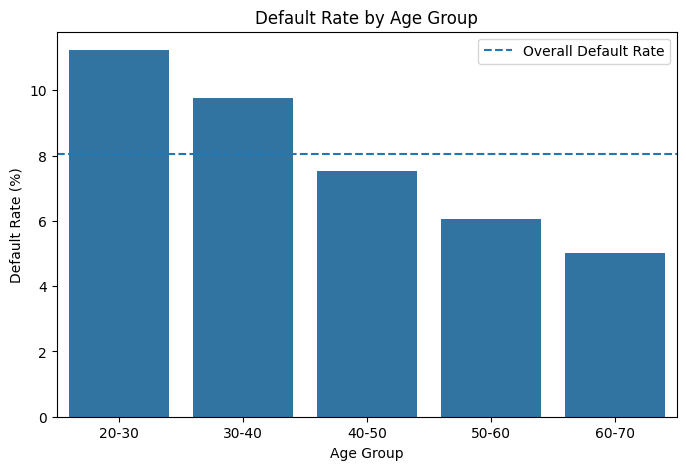

In [36]:
overall_default_rate = app['TARGET'].mean() * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_group_summary,
    x='AGE_GROUP',
    y='DEFAULT_RATE'
)

plt.axhline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')
plt.legend()

plt.show()

## Income-Group Analysis

In [37]:
app['INCOME_GROUP'] = pd.qcut(
    app['AMT_INCOME_TOTAL'],
    q=5,
    duplicates='drop'
)

In [38]:
income_group_summary = (
    app.groupby(
        'INCOME_GROUP',
        observed=False
    )
    .agg(
        APPLICANT_COUNT=('TARGET', 'size'),
        DEFAULT_COUNT=('TARGET', 'sum'),
        DEFAULT_RATE=('TARGET', 'mean')
    )
    .reset_index()
)

income_group_summary['DEFAULT_RATE'] *= 100

income_group_summary

,INCOME_GROUP,APPLICANT_COUNT,DEFAULT_COUNT,DEFAULT_RATE
0,"(25649.999, 99000.0]",10390,845,8.132820
1,"(99000.0, 135000.0]",13937,1208,8.667576
2,"(135000.0, 164610.0]",5673,528,9.307245
3,"(164610.0, 225000.0]",12265,943,7.688545
4,"(225000.0, 117000000.0]",7735,502,6.489981


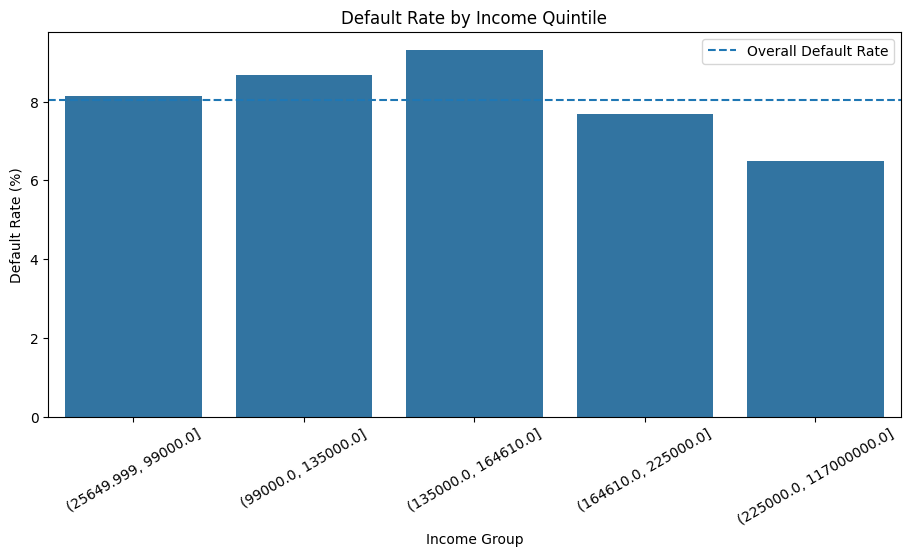

In [39]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=income_group_summary,
    x='INCOME_GROUP',
    y='DEFAULT_RATE'
)

plt.axhline(
    overall_default_rate,
    linestyle='--',
    label='Overall Default Rate'
)

plt.title('Default Rate by Income Quintile')
plt.xlabel('Income Group')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=30)
plt.legend()

plt.show()

## Correlation Analysis

In [42]:
correlation_features = [
    'TARGET',
    'AGE',
    'EMPLOYMENT_YEARS',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS'
]

corr_matrix = (
    app[correlation_features]
    .corr()
)

corr_matrix

,TARGET,AGE,EMPLOYMENT_YEARS,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS
TARGET,1.000000,-0.076792,-0.076535,0.010895,-0.032424,-0.012395,0.026367,0.012993
AGE,-0.076792,1.000000,0.352122,-0.016006,0.059332,-0.007724,-0.329270,-0.277247
EMPLOYMENT_YEARS,-0.076535,0.352122,1.000000,0.003458,0.097865,0.062105,-0.063199,-0.032988
AMT_INCOME_TOTAL,0.010895,-0.016006,0.003458,1.000000,0.069318,0.083011,0.009591,0.011228
AMT_CREDIT,-0.032424,0.059332,0.097865,0.069318,1.000000,0.769501,0.004979,0.064000
AMT_ANNUITY,-0.012395,-0.007724,0.062105,0.083011,0.769501,1.000000,0.026187,0.077381
CNT_CHILDREN,0.026367,-0.329270,-0.063199,0.009591,0.004979,0.026187,1.000000,0.880453
CNT_FAM_MEMBERS,0.012993,-0.277247,-0.032988,0.011228,0.064000,0.077381,0.880453,1.000000


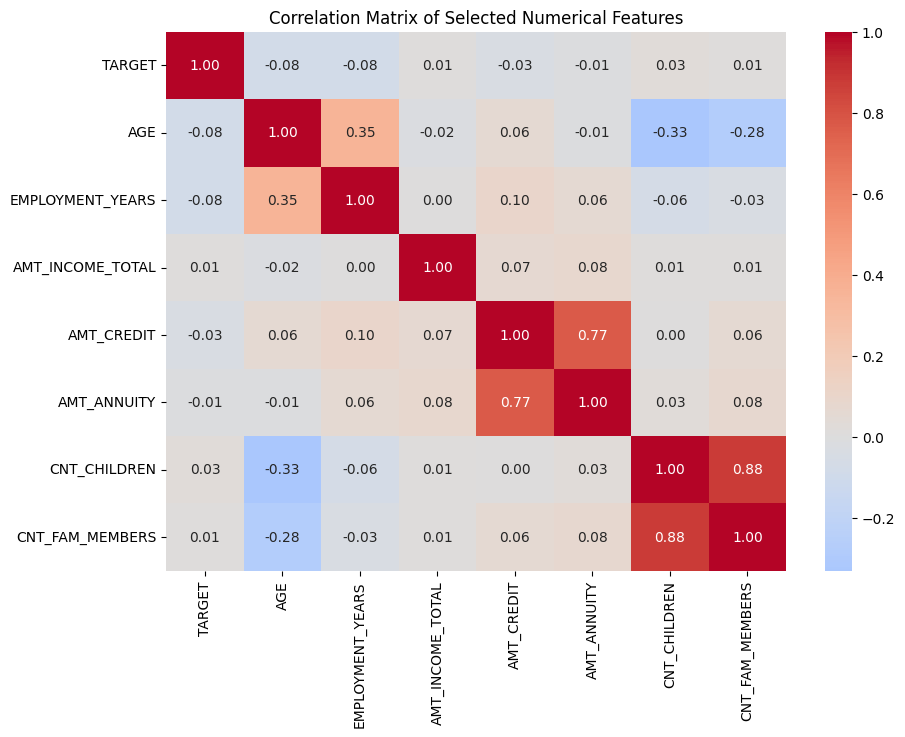

In [43]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Selected Numerical Features')

plt.show()

## Target Correlations

In [44]:
target_correlations = (
    corr_matrix['TARGET']
    .drop('TARGET')
    .sort_values()
)

target_correlations

AGE                -0.076792
EMPLOYMENT_YEARS   -0.076535
AMT_CREDIT         -0.032424
AMT_ANNUITY        -0.012395
AMT_INCOME_TOTAL    0.010895
CNT_FAM_MEMBERS     0.012993
CNT_CHILDREN        0.026367
Name: TARGET, dtype: float64

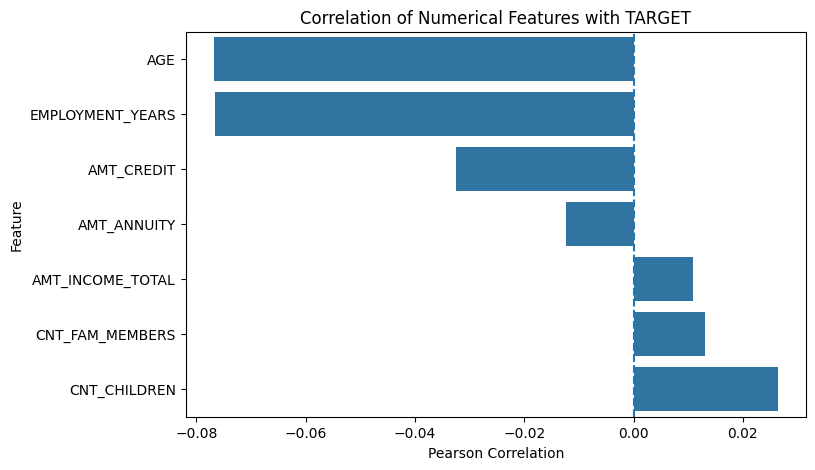

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=target_correlations.values,
    y=target_correlations.index
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title('Correlation of Numerical Features with TARGET')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')

plt.show()

# Key EDA Insights

1. The target variable was highly imbalanced, with approximately 8% of applicants experiencing repayment difficulties.

2. Younger applicants showed higher repayment risk. Default rate decreased consistently from approximately 11.2% among applicants aged 20–30 to 5.0% among applicants aged 60–70.

3. Applicants with repayment difficulties had shorter employment histories, suggesting that employment stability may contain useful predictive information.

4. Income contained extreme outliers and was highly right-skewed. Median income was therefore more representative than mean income when comparing customer groups.

5. The highest-income group had the lowest observed default rate, but the relationship between income and default risk was not monotonic.

6. Raw credit amount and annuity amount showed limited separation between defaulters and non-defaulters, motivating the creation of affordability-based ratio features.

7. Several categorical variables, including education, income type, housing type, occupation, family status, and gender, showed differences in default rates.

8. Rare categorical groups were interpreted cautiously because default rates calculated from small samples may be unstable.

9. Numerical features showed weak individual Pearson correlations with TARGET, suggesting that nonlinear relationships and feature interactions may be important.

10. Strong correlations were observed between AMT_CREDIT and AMT_ANNUITY, and between CNT_CHILDREN and CNT_FAM_MEMBERS, indicating potential redundant information and multicollinearity.